In [5]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import pandas as pd
import torch
import torch.nn as nn
import torchdiffeq as ode
from cubic_spline import CSpline
from torch.fft import fft, ifft
import scipy.io

def RBF(x1, x2, params):
    length_scale, output_scale = params 
    diffs = np.expand_dims(x1 / length_scale, 1) - \
            np.expand_dims(x2 / length_scale, 0)
    r2 = np.sum(diffs**2, axis=2)
    return output_scale * np.exp(-0.5 * r2)

def generate_gaussain_sample(gp_params,N,T):
    gp_samples = np.zeros((N,T))
    length_scale, output_scale = gp_params 
    jitter = 1e-10
    X = np.linspace(0.0, 1.0, T)[:,None]
    K = RBF(X, X, gp_params)
    L = np.linalg.cholesky(K + jitter*np.eye(T))
    for i in range(N):
        gp_sample = np.dot(L, np.random.normal(loc=0,scale=1,size=T))
        gp_samples[i,:] = gp_sample
    return gp_samples

class genc2(nn.Module):
    def __init__(self, kk, u0):
        super(genc2, self).__init__()
        self.D = 0.01
        self.K = 0.01
        self.kk = kk
        self.u0 = u0
        self.fit_data=None 
    
    def forward(self, t, x):
        u0 = self.u0
        ut = self.fit_data.fit(t).expand(u0.shape)
        u_b = u0+ut
        s_tilde = fft(x,axis=1)
        
        gu = self.D*ifft(-1*self.kk**2*s_tilde,axis=1).real +\
            self.K*x**2 + u_b #dr方程 
        return(gu)
    
def gen_one2(xx,yy,u):
    #yy = torch.cos(2*np.pi*xx/L)
    u0 = torch.sin(2*np.pi*xx/L).unsqueeze(0)
    tt = torch.linspace(0, T, Nt)
    
    k = torch.tensor(kk).unsqueeze(0)
    gend = genc2(k,u0)
    
    funcu = CSpline(tt, u[0])
    gend.fit_data = funcu
    
    sol = ode.odeint(gend, yy.unsqueeze(0), tt, rtol=1e-6, atol=1e-8, method='dopri5')
    #sol = ode.odeint(gend, wwm, tt, rtol=1e-6, atol=1e-8, method='euler',options={'step_size':0.01})
    return(xx, tt, sol[:,0].numpy())

Ntr = 10

Nx = 64
Nt = 1000
T = 1
L = 1
kk = np.concatenate((np.arange(0, Nx/2),np.array([0]),np.arange(-Nx/2+1, 0)))*2*np.pi/L
xx = torch.linspace(0, L, Nx+1)[:-1]

length_scale = 0.2
output_scale = 2.0
gp_params = (length_scale, output_scale)

'''
y0 = torch.cos(2*np.pi*xx/L)
i = 0
while i <= 0:
    try:
        sensor = torch.tensor(generate_gaussain_sample(gp_params, 1, Nt))
        sensor = sensor - torch.min(sensor)
        x,t,s = gen_one2(xx,y0,sensor)
        #x,t,s = gen_one2(xx,torch.tensor(s[-1]),sensor)
        #x,t,s = gen_one2(xx,torch.tensor(s[-1]),sensor)
        #x,t,s = gen_one2(xx,torch.tensor(s[-1]),sensor)
        #x,t,s = gen_one2(xx,torch.tensor(s[-1]),sensor)
        #x,t,s = gen_one2(xx,torch.tensor(s[-1]),sensor)
        #x,t,s = gen_one2(xx,torch.tensor(s[-1]),sensor)
        yy = torch.tensor(s[-1])
    except:
        print("error")
    else:
        print("pass!")
        i = 1
'''

ext_threshold = 100
u_train = np.zeros((Ntr,Nx))
s_train = np.zeros((Ntr,Nx,Nt))
i = 0
while i<Ntr:
    print("train",i,Ntr)
    try:
        sensor = torch.tensor(generate_gaussain_sample(gp_params, 1, Nx))
        #print("xx:",xx.shape,"sensor:",sensor.shape,"u:",torch.zeros(len(xx)).shape)
        x,t,s = gen_one2(xx,sensor[0],torch.zeros(1,Nt))
        u_train[i] = sensor 
        s_train[i] = np.real(s).transpose()
    except Exception as e:
        print("error:", e)
    else:
        if np.isnan(s_train[i]).any():
            print("isnan")
        elif np.max(s_train[i])>ext_threshold:
            print("ext_threshold")
        else:
            i=i+1     



train 0 10
train 1 10
train 2 10
train 3 10
train 4 10
train 5 10
train 6 10
train 7 10
train 8 10
train 9 10


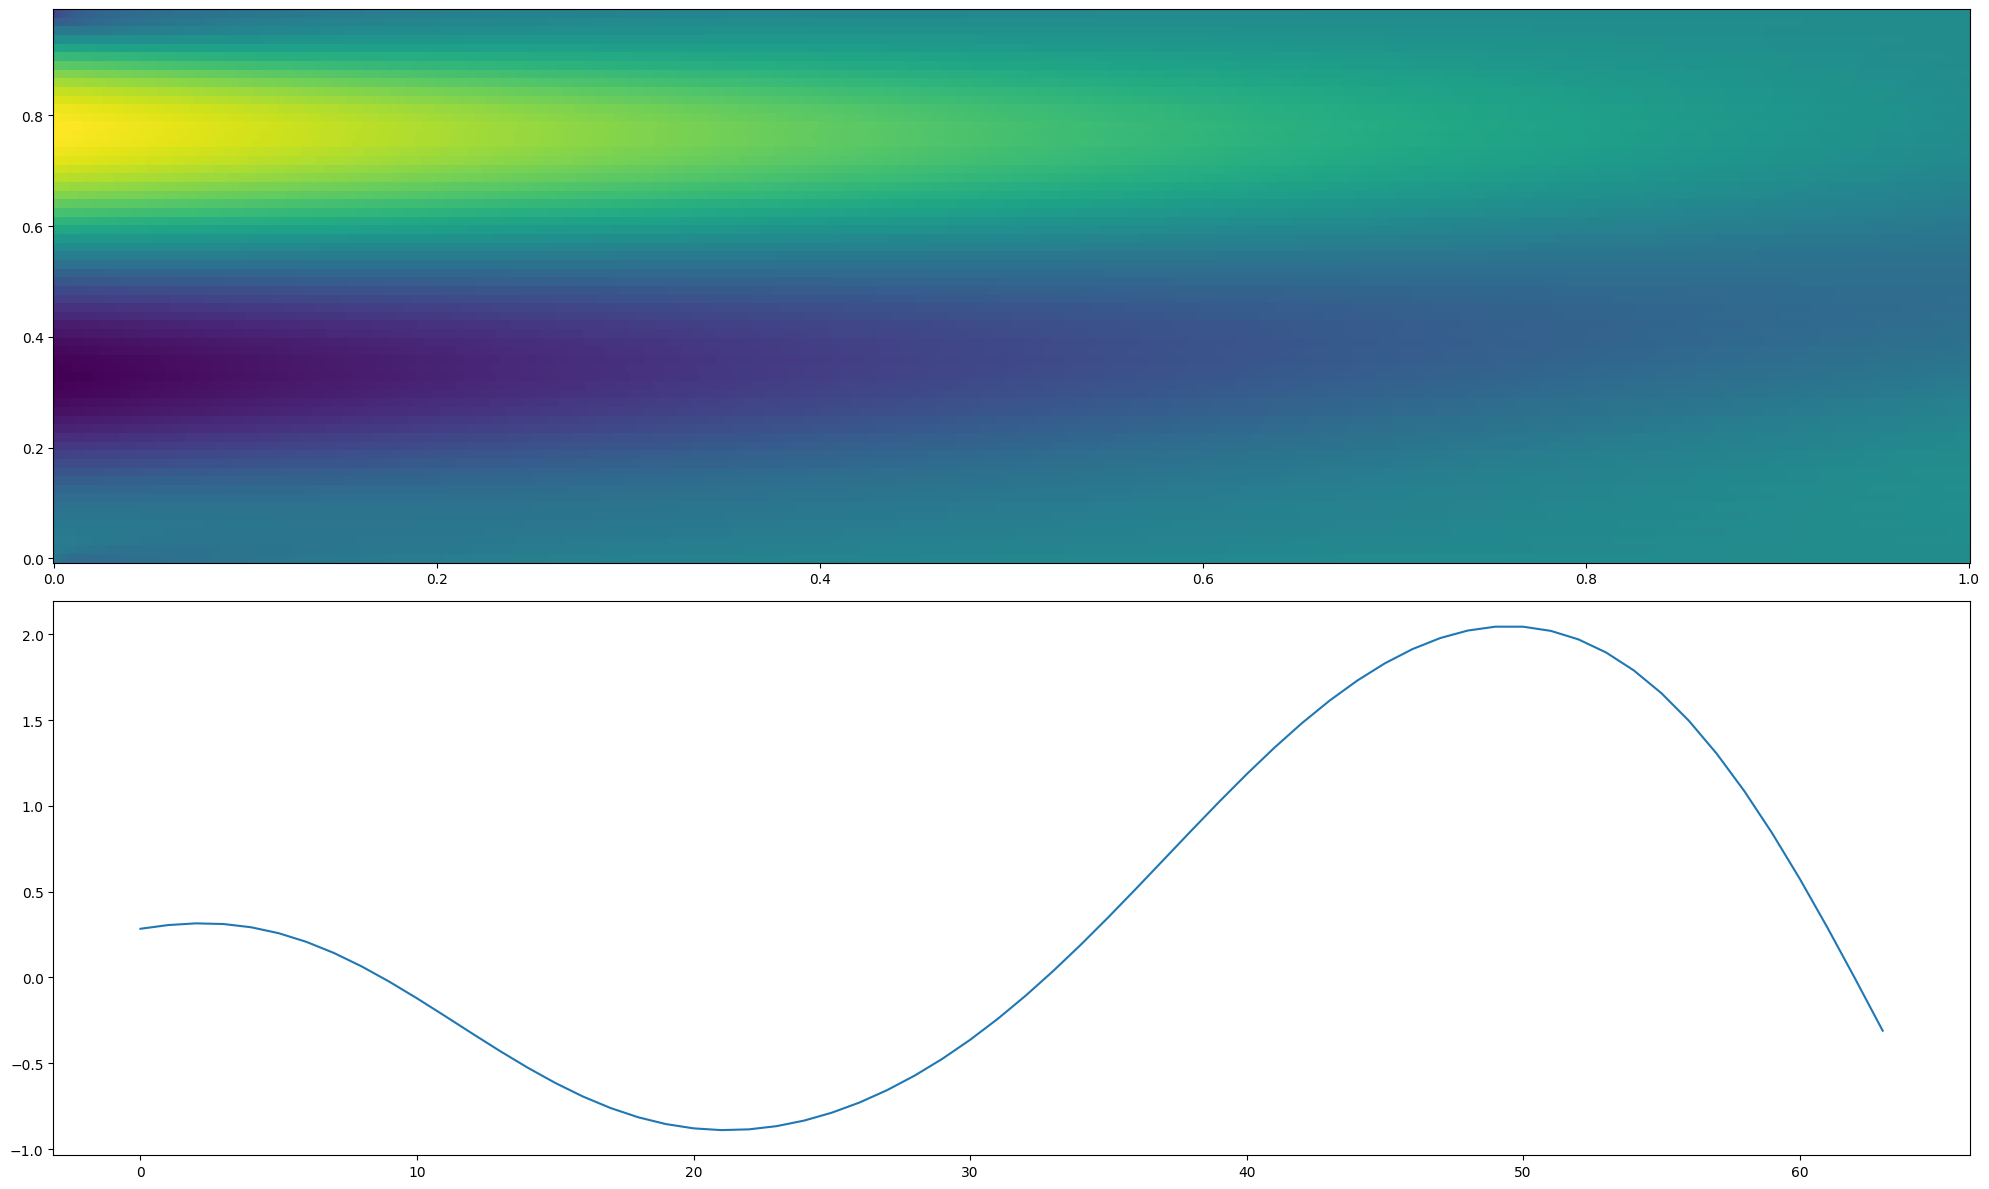

In [13]:
i = 7
s = s_train[i].transpose()
xx_mesh, tt_mesh = np.meshgrid(x, t)
fig, ax = plt.subplots(2, 1, figsize=(20, 12))
fig.set_tight_layout(True)
ax[0].pcolormesh(tt_mesh, xx_mesh, s, vmin=s.min(), vmax=s.max())
ax[1].plot(u_train[i])
plt.show()
